<a href="https://colab.research.google.com/github/bonnandrei24/Statistical-Theory-Buenaventura-Repository/blob/main/FA10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STATISTICAL THEORY - FA 10 SOLUTIONS
SUBMITTED BY: Bonn Andrei M. Buenaventura

## PROBLEM 1 ##
Result (a): Standard Error of Estimate (s_YX) = 1.4577 [cite: 12]
Result (b): Standard Error of Difference (s_X-Y) = 0.5217 [cite: 12]


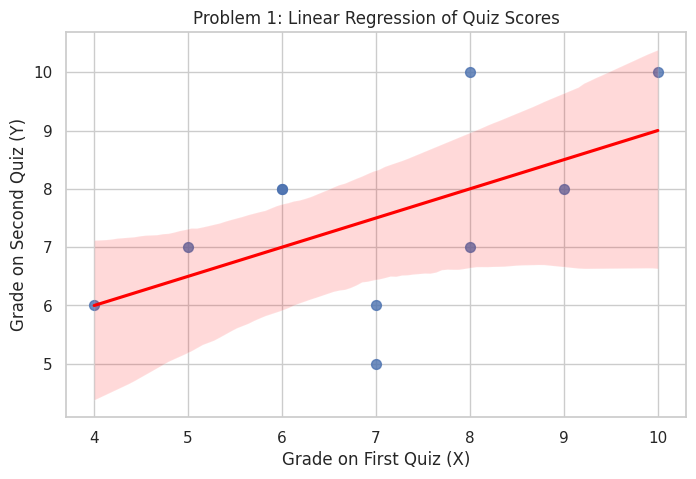


## PROBLEM 2 ##
Correlation (a) Temperature vs Pressure: 0.7321
Correlation (b) Transformed Variables: 0.7321
Justification: The results are identical. Correlation is invariant under linear transformations[cite: 20].


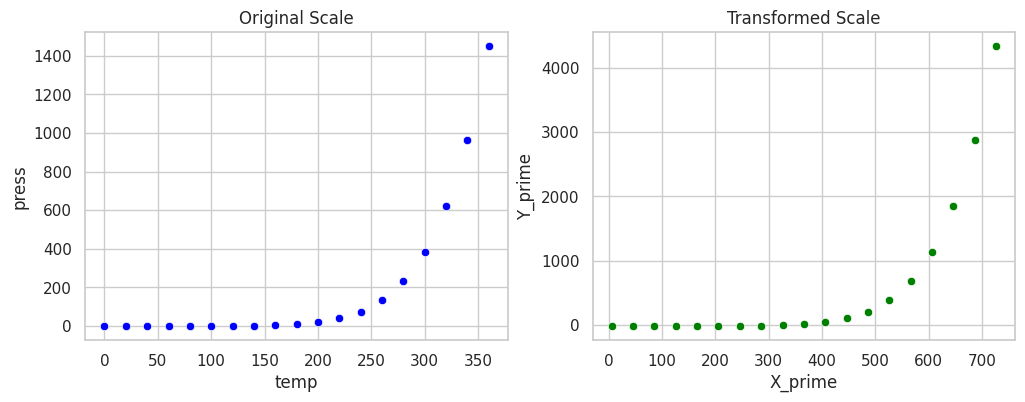


## PROBLEM 3 ##
Correlation (a) Departure Delay vs Arrival Delay: 0.9148
Correlation (b) Transformed Delay Variables: 0.9148
Interpretation (d): The strength of the relationship is very strong and the direction is positive[cite: 33].


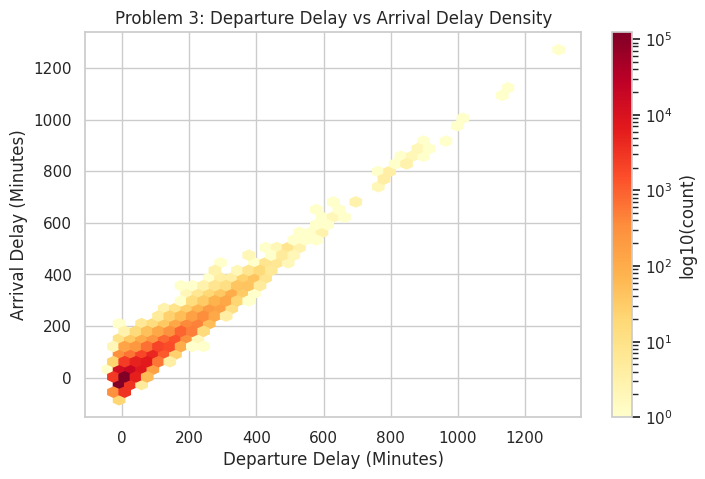


## PROBLEM 4 ##
Estimated Regression Equation:
Y_hat = -14.508 + 1.477(X1) + 1.010(X2) + 0.689(X3) + -0.088(X4) + -0.085(X5) + -3.949(X6)

Interpretation of Departure Delay (X2): Holding other factors constant, for every 1-minute increase in Departure Delay, the Arrival Delay is expected to increase by 1.010 minutes.
Significance: F-test p-value = 0.0000e+00. Since p < 0.05, the predictors are significantly related to Arrival Delay.
Coefficient of Determination (R^2): 0.8792
Interpretation: Approximately 87.92% of the variance in Arrival Delay is explained by the regression model.


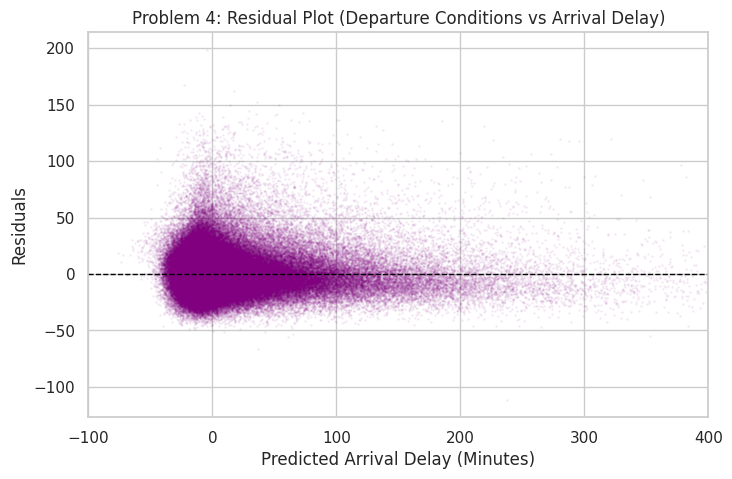

In [6]:
# =================================================================
# AUTHOR: Bonn Andrei M. Buenaventura
# COURSE: APM1111 - Statistical Theory
# ASSIGNMENT: FA 10 - Correlation and Regression Analysis
# =================================================================

# Install necessary package for nycflights13 data
!pip install nycflights13 -q

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from nycflights13 import flights
import scipy.stats as stats
import warnings

# Suppress FutureWarnings to keep the output clean
warnings.simplefilter(action='ignore', category=FutureWarning)

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

print(f"{'='*60}")
print(f"STATISTICAL THEORY - FA 10 SOLUTIONS")
print(f"SUBMITTED BY: Bonn Andrei M. Buenaventura")
print(f"{'='*60}\n")

# --- PROBLEM 1: Quiz Scores Analysis ---
print("## PROBLEM 1 ##")
# [cite: 12-14]
x = np.array([6, 5, 8, 8, 7, 6, 10, 4, 9, 7])
y = np.array([8, 7, 7, 10, 5, 8, 10, 6, 8, 6])

# (a) Standard error of estimate s_{Y.X}
slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
y_pred = intercept + slope * x
s_yx = np.sqrt(np.sum((y - y_pred)**2) / (len(x) - 2))

# (b) Standard error of difference s_{X-Y}
diff = x - y
s_xy_diff = np.std(diff, ddof=1) / np.sqrt(len(x))

print(f"Result (a): Standard Error of Estimate (s_YX) = {s_yx:.4f} [cite: 12]")
print(f"Result (b): Standard Error of Difference (s_X-Y) = {s_xy_diff:.4f} [cite: 12]")

plt.figure()
sns.regplot(x=x, y=y, scatter_kws={'s':50}, line_kws={"color": "red"})
plt.title("Problem 1: Linear Regression of Quiz Scores")
plt.xlabel("Grade on First Quiz (X)")
plt.ylabel("Grade on Second Quiz (Y)")
plt.show()


# --- PROBLEM 2: Vapor Pressure Transformation ---
print("\n## PROBLEM 2 ##")
# [cite: 15-22]
p_data = {
    'temp': [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360],
    'press': [0.0002, 0.0012, 0.006, 0.03, 0.09, 0.27, 0.75, 1.85, 4.38, 9.59, 19.7, 38.8, 73.2, 133, 231, 385, 619, 963, 1450]
}
df2 = pd.DataFrame(p_data)

# (a) Original Correlation [cite: 16]
corr_a = df2['temp'].corr(df2['press'])

# (b) Linear Transformation [cite: 18]
df2['X_prime'] = 2 * df2['temp'] + 6
df2['Y_prime'] = 3 * df2['press'] - 15
corr_b = df2['X_prime'].corr(df2['Y_prime'])

print(f"Correlation (a) Temperature vs Pressure: {corr_a:.4f}")
print(f"Correlation (b) Transformed Variables: {corr_b:.4f}")
print("Justification: The results are identical. Correlation is invariant under linear transformations[cite: 20].")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=df2['temp'], y=df2['press'], ax=ax1, color='blue').set(title='Original Scale')
sns.scatterplot(x=df2['X_prime'], y=df2['Y_prime'], ax=ax2, color='green').set(title='Transformed Scale')
plt.show()


# --- PROBLEM 3: NYC Flights Correlation ---
print("\n## PROBLEM 3 ##")
# [cite: 26-36]
df3 = flights.dropna(subset=['dep_delay', 'arr_delay']).copy()

# (a) Correlation [cite: 27]
corr3a = df3['dep_delay'].corr(df3['arr_delay'])

# (b) Transformation [cite: 28-30]
x_prime3 = 2 * df3['dep_delay'] + 10
y_prime3 = 0.5 * df3['arr_delay'] - 5
corr3b = x_prime3.corr(y_prime3)

print(f"Correlation (a) Departure Delay vs Arrival Delay: {corr3a:.4f}")
print(f"Correlation (b) Transformed Delay Variables: {corr3b:.4f}")
print(f"Interpretation (d): The strength of the relationship is very strong and the direction is positive[cite: 33].")

plt.figure()
plt.hexbin(df3['dep_delay'], df3['arr_delay'], gridsize=40, cmap='YlOrRd', bins='log')
plt.colorbar(label='log10(count)')
plt.title("Problem 3: Departure Delay vs Arrival Delay Density")
plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Arrival Delay (Minutes)")
plt.show()


# --- PROBLEM 4: Multiple Linear Regression ---
print("\n## PROBLEM 4 ##")
# [cite: 37-55]
df4 = df3.copy()
df4['X1'] = (df4['dep_delay'] > 0).astype(int) # [cite: 41]
df4['X2'] = df4['dep_delay'] # [cite: 42]
df4['X3'] = df4['air_time'] # [cite: 42]
df4['X4'] = df4['distance'] # [cite: 43]
df4['X5'] = df4['hour']     # [cite: 43]
# Major carrier defined as AA, DL, UA, or WN [cite: 46]
df4['X6'] = df4['carrier'].isin(['AA', 'DL', 'UA', 'WN']).astype(int)

X = sm.add_constant(df4[['X1', 'X2', 'X3', 'X4', 'X5', 'X6']])
Y = df4['arr_delay']
model = sm.OLS(Y, X).fit()

# (b) Estimated regression equation [cite: 52]
c = model.params
print("Estimated Regression Equation:")
print(f"Y_hat = {c.iloc[0]:.3f} + {c.iloc[1]:.3f}(X1) + {c.iloc[2]:.3f}(X2) + {c.iloc[3]:.3f}(X3) + {c.iloc[4]:.3f}(X4) + {c.iloc[5]:.3f}(X5) + {c.iloc[6]:.3f}(X6)")

# (c) Interpret coefficient of X2 [cite: 53]
print(f"\nInterpretation of Departure Delay (X2): Holding other factors constant, for every 1-minute increase in Departure Delay, the Arrival Delay is expected to increase by {c.iloc[2]:.3f} minutes.")

# (d) Significance test [cite: 54]
print(f"Significance: F-test p-value = {model.f_pvalue:.4e}. Since p < 0.05, the predictors are significantly related to Arrival Delay.")

# (e) R-squared [cite: 55]
print(f"Coefficient of Determination (R^2): {model.rsquared:.4f}")
print(f"Interpretation: Approximately {model.rsquared*100:.2f}% of the variance in Arrival Delay is explained by the regression model.")

# Visualization 4: Residual Diagnostics
plt.figure()
plt.scatter(model.fittedvalues, model.resid, alpha=0.05, s=1, color='purple')
plt.axhline(0, color='black', lw=1, linestyle='--')
plt.title("Problem 4: Residual Plot (Departure Conditions vs Arrival Delay)")
plt.xlabel("Predicted Arrival Delay (Minutes)")
plt.ylabel("Residuals")
plt.xlim(-100, 400)
plt.show()